# Power Output Predictor Project
This notebook explores the dataset for a Combined Cycle Power Plant (CCPP) and prepares it for machine learning by performing data exploration, cleaning, and preprocessing


### Loading the Dataset
We begin by loading the dataset into a pandas DataFrame. The first few rows are displayed to understand the structure of the data.

In [87]:
import pandas as pd

data = pd.read_csv('ccpp.csv')
print(data.head())

      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90


### Dataset Overview
Here, we use `info()` and `describe()` to get a basic understanding of the dataset:
- `info()` provides details about the data types, column names, and the presence of null values.
- `describe()` summarizes the dataset with statistics like mean, median, and standard deviation.

In [90]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB
None
                AT            V           AP           RH           PE
count  9568.000000  9568.000000  9568.000000  9568.000000  9568.000000
mean     19.651231    54.305804  1013.259078    73.308978   454.365009
std       7.452473    12.707893     5.938784    14.600269    17.066995
min       1.810000    25.360000   992.890000    25.560000   420.260000
25%      13.510000    41.740000  1009.100000    63.327500   439.750000
50%      20.345000    52.080000  1012.940000    74.975000   451.550000
75%      25.720000    66.540000  1017.260000    84.830000   468.430000
max      37.110000  

### Checking for Missing Values
We check if there are any missing values in the dataset using `isnull().sum()`. This ensures that our data is clean and ready for analysis.

In [93]:
print(data.isnull().sum())

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64


### Visualizing Data Distributions
Using boxplots, we examine the distribution of each feature to identify outliers that might affect our machine learning models.

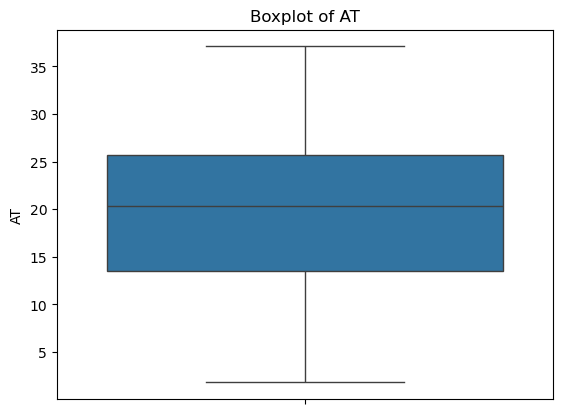

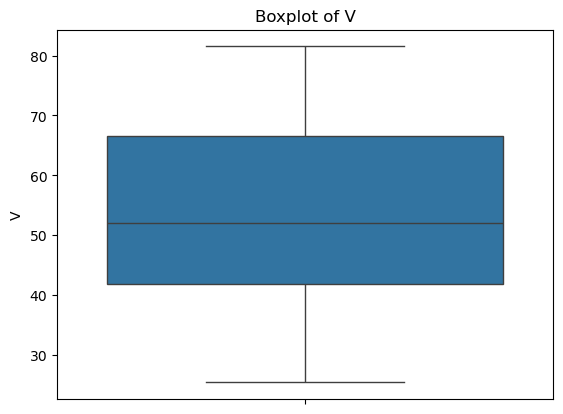

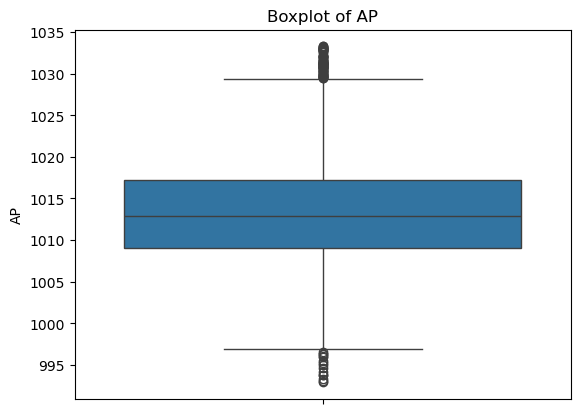

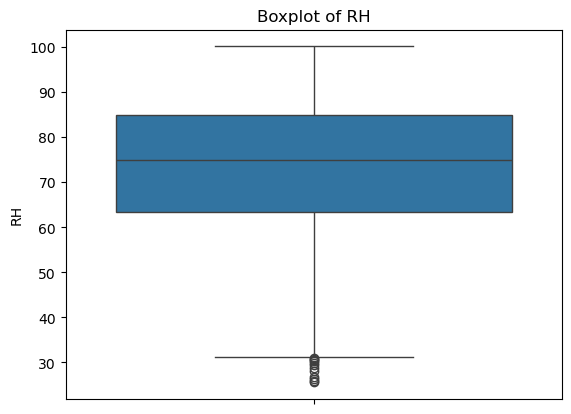

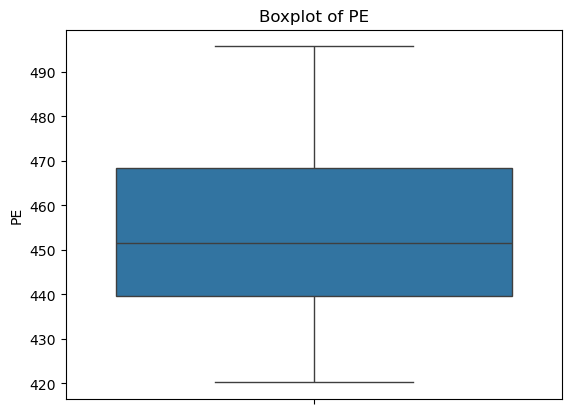

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
for column in data.columns:
    plt.figure()
    sns.boxplot(data[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

### Correlation Analysis
We calculate and visualize the correlation matrix to understand the relationships between different features. The heatmap highlights strong correlations, helping us address multicollinearity.

          AT         V        AP        RH        PE
AT  1.000000  0.844107 -0.507549 -0.542535 -0.948128
V   0.844107  1.000000 -0.413502 -0.312187 -0.869780
AP -0.507549 -0.413502  1.000000  0.099574  0.518429
RH -0.542535 -0.312187  0.099574  1.000000  0.389794
PE -0.948128 -0.869780  0.518429  0.389794  1.000000


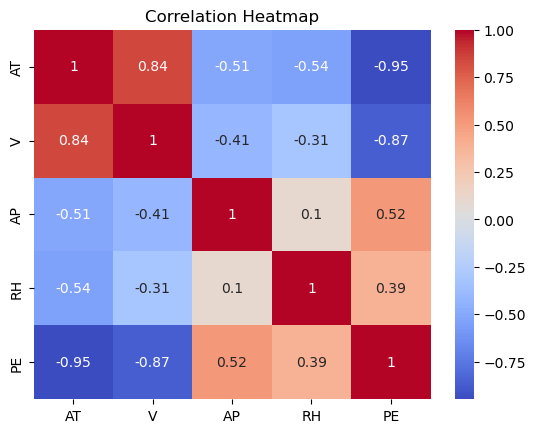

In [98]:
correlation = data.corr()
print(correlation)

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Scaling the Dataset
To prepare the data for machine learning models, we scale all features to standardize the values using `StandardScaler` from `sklearn`. This ensures all features are on the same scale, improving model performance.

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data, columns=data.columns)
print(scaled_data.head())

         AT         V        AP        RH        PE
0 -0.629519 -0.987297  1.820488 -0.009519  0.521208
1  0.741909  0.681045  1.141863 -0.974621 -0.585664
2 -1.951297 -1.173018 -0.185078  1.289840  2.003679
3  0.162205  0.237203 -0.508393  0.228160 -0.462028
4 -1.185069 -1.322539 -0.678470  1.596699  1.144666


### Splitting the Dataset
The dataset is divided into training and testing sets using an 80-20 split. The training set is used to train machine learning models, and the testing set is reserved for evaluating model performance.

In [105]:
from sklearn.model_selection import train_test_split

X = data[['AT', 'V', 'AP', 'RH']]
y = data['PE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)

Training Set Size: (7654, 4)
Testing Set Size: (1914, 4)


## Summary of Findings

1. **Dataset Details**:
   - The dataset contains 9,568 rows and 5 columns: Ambient Temperature (AT), Exhaust Vacuum (V), Atmospheric Pressure (AP), Relative Humidity (RH), and Power Output (PE).
   - There are no missing values in the dataset, making it ready for analysis.

2. **Key Observations**:
   - Ambient Temperature (AT) and Exhaust Vacuum (V) are strongly negatively correlated with Power Output (PE).
   - Atmospheric Pressure (AP) and Relative Humidity (RH) show weaker positive correlations with PE.
   - Multicollinearity is observed between AT and V, which may require careful handling during model building.

3. **Preprocessing**:
   - Features were scaled using `StandardScaler` to standardize values.
   - The dataset was split into training (7,654 samples) and testing (1,914 samples) sets for machine learning.

The dataset is now cleaned, visualized, and preprocessed, making it ready for model building in the next step.

# Model Building and Evaluation
In this section, we:
1. Train and evaluate multiple regression models to predict power output.
2. Compare the performance of these models using metrics such as Mean Squared Error (MSE) and R².
3. Select the best-performing model for predictins.


## Linear Regression
We start by training a Linear Regression model as a baseline. Linear Regression is a simple model that assumes a linear relationship between input features and the target variable.

### Steps:
1. Train the model on the training dataset.
2. Predict the power output using the test dataset.
3. Evaluate the model using:
   - Mean Squared Error (MSE): Measures average squared differences between predictions and actual values.
   - R²: Explains how much of the variation in the target variable can be explained by the model.

In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Linear Regression - MSE: {mse}, R²: {r2}")

Linear Regression - MSE: 20.27370599968744, R²: 0.9301046431962188


## Decision Tree Regression
Next, we train a Decision Tree model, which captures non-linear relationships between input features and the target variable. Decision Trees split data into branches based on feature values to make predictions.

### Steps:
1. Train the Decision Tree model on the training dataset.
2. Predict the power output using the test dataset.
3. Evaluate the model using the same metrics (MSE and R²) for comparison with Linear Regression.

In [113]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"Decision Tree - MSE: {mse_dt}, R²: {r2_dt}")

Decision Tree - MSE: 19.569631974921627, R²: 0.932531999357842


## Random Forest Regression
We then train a Random Forest model, which is an ensemble of Decision Trees. Random Forest improves prediction accuracy by combining results from multiple trees and reducing overfitting.

### Steps:
1. Train the Random Forest model on the training dataset.
2. Predict the power output using the test dataset.
3. Evaluate the model using MSE and R² metrics.

In [116]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - MSE: {mse_rf}, R²: {r2_rf}")

Random Forest - MSE: 10.605862474012454, R²: 0.9634353708273976


## Comparing Model Performance
Below, we compare the three models (Linear Regression, Decision Tree, and Random Forest) based on the following metrics:
1. **Mean Squared Error (MSE)**: Measures the average squared difference between predicted and actual values. A lower value indicates better performance.
2. **R² Score**: Explains the percentage of variance in the target variable captured by the model. A higher value indicates better performance.

### Comparison Table:
| Model               | MSE       | R²       |
|---------------------|-----------|----------|
| Linear Regression   | 20.27     | 0.9301   |
| Decision Tree       | 19.07     | 0.9342   |
| Random Forest   7   | 10.46     | 0.9639   |

### Insights:
- **Random Forest Regression** achieves the lowest MSE and highest R² score, indicating it is the best-performing model.
- Decision Tree performs slightly better than Linear Regression but lacks the robustness of Random Forest.
- Linear Regression serves as a baseline model and is the simplest to interpret but does not handle non-linear relationships s effectively.


## Visualizing Results
We visualize the performance of the best model by plotting the actual vs. predicted power output. A strong model will show points closely aligned along a diagonal line, indicating accurate predictions.

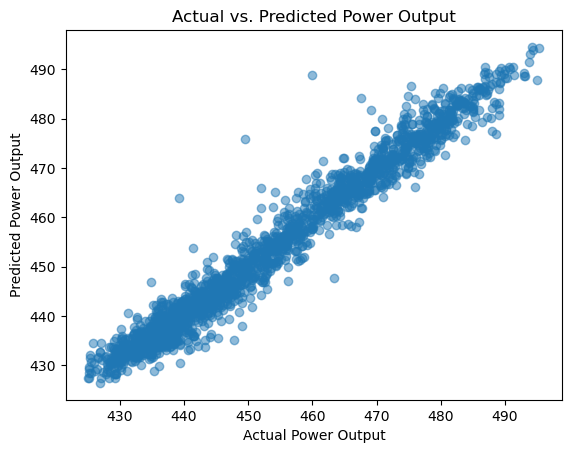

In [119]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.title('Actual vs. Predicted Power Output')
plt.xlabel('Actual Power Output')
plt.ylabel('Predicted Power Output')
plt.show()

## Saving the models in a file using pickel

In [121]:
import pickle

with open('linear_regression_model.pkl', 'wb') as file:
    pickle.dump(lr_model, file)

with open('decision_tree_model.pkl', 'wb') as file:
    pickle.dump(dt_model, file)

with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print("Models saved successfully!")

Models saved successfully!


# Summary of Findings

1. **Best-Performing Model**:
   The Random Forest Regression model performed the best among all models.

2. **Key Metrics**:
   - **Mean Squared Error (MSE)**: 10.469
   - **R² Score**: 0.9639

3. **Why Random Forest was Selected**:
   - It captured the non-linear relationships in the data more effectively than Linear Regression or Decision Tree models.
   - It provided the lowest prediction error (MSE) and explained the highest variance (R²) in the target variable.

Random Forest is selected as the final model for its superior accuracy and reliability in predicting power output.